[ 0. 10. 20. 30. 40. 50.]


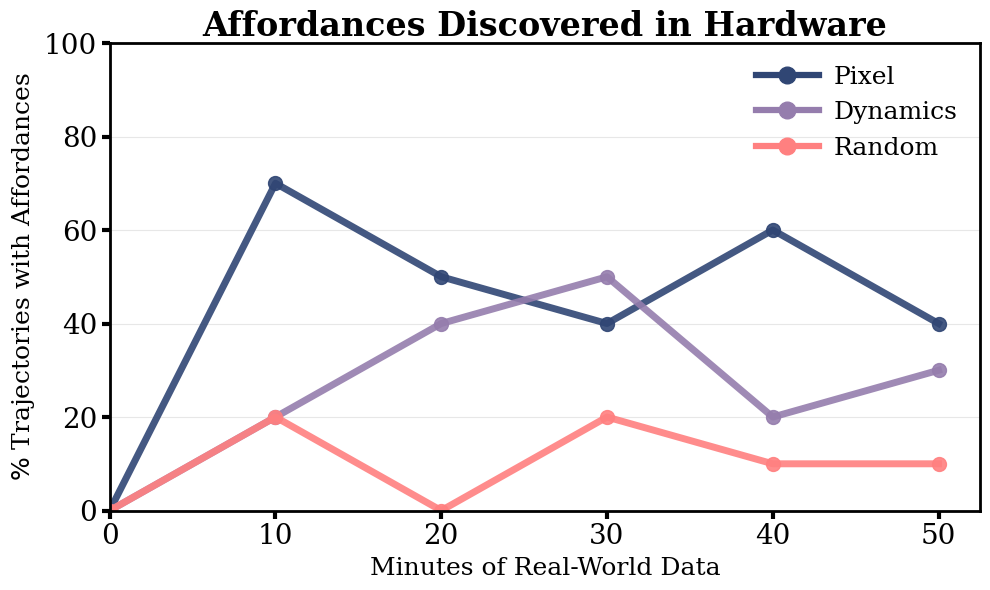

In [46]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import json 
import numpy as np

# Configure Matplotlib to use LaTeX for text rendering
plt.rcParams['text.usetex'] = False
plt.rcParams['pdf.fonttype'] = 42  # Ensures TrueType fonts are used
plt.rcParams['ps.fonttype'] = 42   # Ensures TrueType fonts for PostScript output
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Didot'] + plt.rcParams['font.serif']

# Set up bold face for figure generation
mpl.rcParams['lines.linewidth'] = 5
mpl.rcParams['lines.markersize'] = 10
mpl.rcParams['lines.markeredgewidth'] = 1
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['figure.titlesize'] = 25
mpl.rcParams['figure.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 20
# mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.titlepad'] = 5
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['xtick.major.pad'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['ytick.major.pad'] = 3
mpl.rcParams['figure.subplot.hspace'] = 0.85
mpl.rcParams["axes.labelpad"] = 5

# Define box plot properties
bw_props = dict(linestyle='-', linewidth=2.5, color='black')
boxplot_kwargs = dict(
    vert=True,
    patch_artist=True,
    widths=0.5,
    whis=[0, 100],
    showfliers=False,
    medianprops=bw_props,
    boxprops=bw_props,
    capprops=bw_props,
    whiskerprops=bw_props,
    flierprops=dict(linestyle='', markersize=10, markeredgewidth=2, color='black'),
    showmeans=False,
    meanline=True
)

# import data as json, this can be numpy or array too
# with open(f"/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/contact/contacts_seed_20.json", "r") as f:
#     data = json.load(f)

environments = ['door', 'coffee', 'drawer', 'button', 'faucet']
objectives = ['pixel', 'dynamics', 'random']
objective_labels = {'random': 'Random', 'pixel': 'Pixel', 'dynamics': 'Dynamics'}
colors = {'random': '#ff8080', 'pixel': '#304674', 'dynamics': '#957dadff'}

# Prepare data for plotting
plot_data = {
    'random': [0, 20, 0, 20, 10, 10],
    'pixel': [0, 70, 50, 40, 60, 40],
    'dynamics': [0, 20, 40, 50, 20, 30]
}

epochs = np.arange(0, 60, 10)  # [10, 20, 30, 40, 50]
mins = (epochs*180) / 3 // 60
print(mins)

fig, ax = plt.subplots(figsize=(10, 6))

# linestyles = ['-', '--', '-.', ':']  # one per environment

for obj in objectives:
    values = plot_data[obj]

    ax.plot(
        mins,
        values,
        marker='o',
        linewidth=5,
        markersize=10,
        # linestyle=linestyles[env_idx % len(linestyles)],
        color=colors[obj],
        alpha=0.9,
        label=f"{objective_labels[obj]}"
    )

ax.set_xlabel("Minutes of Real-World Data", fontsize=18)
ax.set_ylabel(r"$\%$ Trajectories with Affordances", fontsize=18)
ax.set_xticks(mins)
ax.set_xlim(0)
ax.set_ylim(0, 100)
ax.grid(True, axis='y', alpha=0.3)

# Deduplicate legend entries
from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0], [0],
        color=colors[obj],
        marker='o',
        linewidth=4.5,
        markersize=12,
        label=objective_labels[obj]
    )
    for obj in objectives
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=False,
    fontsize=18,
    handlelength=2.5,
    handletextpad=0.6,
    borderaxespad=0.5
)

plt.title("Affordances Discovered in Hardware", fontsize=24, fontweight='bold')
plt.tight_layout()
plt.show()
fig.savefig("harware_plot.png", dpi=300, bbox_inches='tight')